# White dwarf star structure

We'll investigate white dwarf structure by consider integrating the equation of  hydrostatic equilibrium:

$$\frac{dP}{dr} = - \frac{G M(r)}{r^2}$$

together with continuity:

$$\frac{dM}{dr} = 4\pi r^2 \rho$$

and we'll use the zero-T degenerate equation of state.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

First we'll write our RHS function.  We'll integrate

$${\bf Y} = \left ( \begin{array}{c} m \\ P \end{array} \right )$$

All of our units will be in CGS.

Some physical constants (CGS)

In [2]:
G = 6.67e-8
c = 3.e10
h = 6.63e-27
m_u = 1.66e-24
m_e = 9.11e-28
M_sun = 2.e33

Here's the righthand side function:

In [3]:
def rhs_newton(r, y, rho_func, P_c):
    m, P = y

    rho = rho_func(P)
    
    dmdr = 4.0 * np.pi * r**2 * rho
    
    if r == 0.0:
        dPdr = 0.0
    else:
        dPdr = -G * m / r**2 * rho
        
    return np.array([dmdr, dPdr])

## Degenerate electrons

For zero-T neutron degeneracy, the number density of electrons is

$$n_e = \frac{\rho Y_e}{m_u} = \frac{8\pi}{3h^3} p_F^3 = \frac{8\pi}{3} \left (\frac{m_e c}{h} \right )^3 x_F^3$$

where $x_F = p_F / (m_e c)$.

We'll write this as 

$$\rho = B x_F^3$$

and the pressure is

$$P = \frac{\pi}{3} \left ( \frac{m_e c}{h} \right )^3 m_e c^2 f(x)$$

with we'll write as:

$$P = A f(x)$$

with

$$f(x) = x (2x^2 - 3) (1 + x^2)^{1/2} + 3 \sinh^{-1}(x)$$

Now, we have our EOS as $P(\rho)$, but we need to invert it, $\rho(P)$.  For this
we'll use a root finding algorithm.

In [5]:
from scipy.optimize import brentq

In [6]:
def pres_deg(rho, Y_e=0.5):
    # compute the dimensionless Fermi momentum x = p / mc
    # from rho
    B = 8 * np.pi * m_u / 3.0 * (m_e * c / h)**3 / Y_e
    x = np.cbrt(rho / B)

    # compute the dimensionless pressure
    f = x * (2 * x**2 - 3) * np.sqrt(1 + x**2) + 3 * np.arcsinh(x)

    # compute the pressure scaling
    A = (np.pi / 3) * (m_e * c / h)**3 * m_e * c**2
    
    return A * f
    
def rho_deg(pres, Y_e=0.5):

    # we shouldn't encounter this
    if pres < 0:
        return 0;
        
    A = (np.pi / 3) * (m_e * c / h)**3 * m_e * c**2
    f = pres / A
    
    # find the x that gives us this f
    x = brentq(lambda x: f - (x * (2 * x**2 - 3) *
                              np.sqrt(1 + x**2) + 3 * np.arcsinh(x)),
               0, 1000)
    
    B = 8 * np.pi * m_u / 3.0 * (m_e * c / h)**3 / Y_e
    return B * x**3 

Now we can integrate this.  We'll be integrating from the center outward.  We want to stop when $P \sim 0$.

In [7]:
from scipy.integrate import solve_ivp

we'll use an event to stop the integration

In [8]:
def surface(t, y, rho_func, P_c):
    # return the pressure -- when it is ~zero we will terminate
    # we'll use the central pressure, P_c as the scale
    smallp = P_c / 1.e10
    return y[1] - smallp
surface.terminal = True
surface.direction = -1

we'll pick a large ending radius, since we'll terminate before we end

In [9]:
R_sun = 7.e10
r_end = R_sun

We need initial conditions.  We'll supply the central density and get the pressure from that.  The initial mass ($m(r=0)$) is 0.

In [10]:
rho_c = 2.e9
P_c = pres_deg(rho_c)
P_c

np.float64(1.2338331610469019e+27)

Now we can integrate.  We'll do a grid, running through different central densities.

In [14]:
central_densities = np.logspace(7, 11.5, 30)

mass = []
radius = []
for rho_c in central_densities:
    P_c = pres_deg(rho_c)
    sol = solve_ivp(rhs_newton, (0, r_end), np.array([0.0, P_c]),
                    rtol=1.e-5, atol=1.e-10,
                    args=(rho_deg, P_c), events=surface)
    assert sol.success
    mass.append(sol.y[0, -1])
    radius.append(sol.t[-1])

Now we can plot the mass-radius relation

Text(0, 0.5, 'radius ($R_\\odot$)')

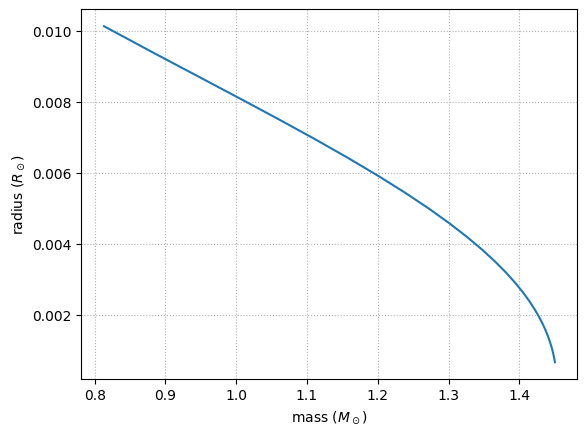

In [15]:
fig, ax = plt.subplots()

ax.plot(np.array(mass) / M_sun, np.array(radius) / R_sun)
ax.grid(ls=":")
ax.set_xlabel(r"mass ($M_\odot$)")
ax.set_ylabel(r"radius ($R_\odot$)")

We see that:

* More massive white dwarfs have smaller radii
* As we approach $1.4 M_\odot$, the radius is going to zero&mdash;this is the Chandrasekhar mass.

## Composition

What is the composition of white dwarfs?

Generally, this depends on the mass of the main sequence progenitor.  More massive progenitors can
achieve more advanced stages of burning in their cores.  The general trend is:

* $M_\mathrm{MS} < 0.3 ~M_\odot$ produce He WDs
* $0.3 ~M_\odot < M_\mathrm{MS} < 8 ~M_\odot$ produce C/O WDs
* $8 ~M_\odot < M_\mathrm{MS} < 11 ~M_\odot$ produce O/Ne WDs

but these boundaries are a bit fuzzy.